# Customer Churn Analysis

## Introduction

This document shows an example Data Science project utilising a dataset built around customer churn. The goal of the modelling was to predict customers that are likely to churn, this was then extended to minimise loss from churning customers.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn). A fictional company's data. There are demographic features as well as billing and service information

### Contents

1. Exploratory Data Analysis
    - The rates of churn
    - Visualise distributions of the numeric features and separate by `Churn` status 
2. Modelling:
    - Feature Engineering
    - Logistic Regression vs. Tree Based Models aiming to optimise ROC-AUC
3. Post tuning to optimize a cost function
    - After choosing a model based on ROC-AUC performance the modelling was extened further by tuning the decision threshold to optimise for a business metric: Minimising money lost from Churning Customers

In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis

### Learning about the columns in the dataset

In [305]:
df = pd.read_csv('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
print(df.columns)
df.head()

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [306]:
df.loc[42]

customerID                   9867-JCZSP
gender                           Female
SeniorCitizen                         0
Partner                             Yes
Dependents                          Yes
tenure                               17
PhoneService                        Yes
MultipleLines                        No
InternetService                      No
OnlineSecurity      No internet service
OnlineBackup        No internet service
DeviceProtection    No internet service
TechSupport         No internet service
StreamingTV         No internet service
StreamingMovies     No internet service
Contract                       One year
PaperlessBilling                     No
PaymentMethod              Mailed check
MonthlyCharges                    20.75
TotalCharges                     418.25
Churn                                No
Name: 42, dtype: object

an example of a single row

a lot of the columns are categories with low cardinality

In [317]:
demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
billing_and_service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']
charges_cols = ['MonthlyCharges', 'TotalCharges']


### Summary of the Dataset

In [327]:
data_description = pd.concat([df.dtypes, df.nunique()], axis=1, keys=['datatype', 'nunique'])
data_description['Notes'] = ''
data_description.loc['customerID', 'Notes'] = 'Customer ID'
data_description.loc[demographic_cols, 'Notes'] = 'Demographic Info'
data_description.loc[billing_and_service_cols, 'Notes'] = 'Billing and Service Info'
data_description.loc['MonthlyCharges', 'Notes'] = 'Charges Amounts'
data_description.loc['TotalCharges', 'Notes'] = 'Charges Amounts - Notice the dtype is a string. This needs to be converted to numeric'
data_description.loc['tenure', 'Notes'] = "Customer's Tenure (in months)"
data_description.loc['Churn', 'Notes'] = 'Churn Yes/No (Target Variable)'
data_description

,datatype,nunique,Notes
customerID,object,7043,Customer ID
gender,object,2,Demographic Info
SeniorCitizen,int64,2,Demographic Info
Partner,object,2,Demographic Info
Dependents,object,2,Demographic Info
tenure,int64,73,Customer's Tenure (in months)
PhoneService,object,2,Billing and Service Info
MultipleLines,object,3,Billing and Service Info
InternetService,object,3,Billing and Service Info
OnlineSecurity,object,3,Billing and Service Info


In [333]:
import pyperclip
pyperclip.copy(data_description.to_markdown())

we can see that TotalCharges is a string for some reason. This is changed into a numeric. Also we create a integer version of churn for use in Correlation Matrices

In [269]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Class Imbalance for Churn

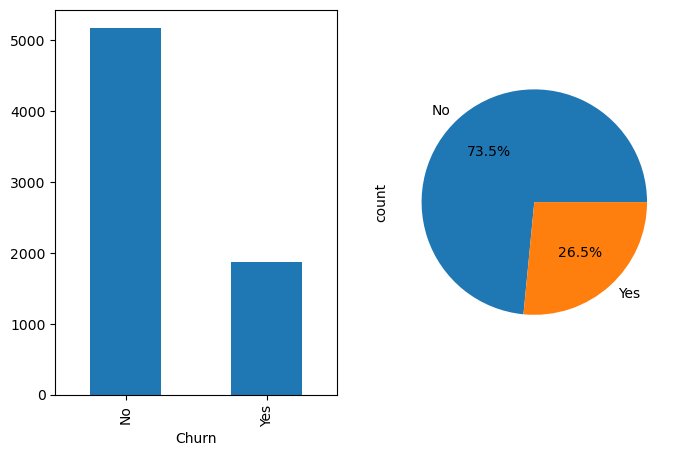

In [270]:
churn_counts = pd.concat(
    [df['Churn'].value_counts(),
    df['Churn'].value_counts(normalize=True)], 
    axis=1)

fig, axes = plt.subplots(1,2, figsize=(8,5))
churn_counts.plot(y='count',kind='bar', ax=axes[0], legend=False)
churn_counts.plot.pie(y='count', autopct=f'%1.1f%%', ax=axes[1], legend=False)

plt.show()

In [271]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

There are 7043 rows, 1869 (26.5%) are customers which churned

### Distribution of Numerical Values with Churn

In [272]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T


Churn                          No          Yes
tenure         count  5174.000000  1869.000000
               mean     37.569965    17.979133
               std      24.113777    19.531123
               min       0.000000     1.000000
               25%      15.000000     2.000000
               50%      38.000000    10.000000
               75%      61.000000    29.000000
               max      72.000000    72.000000
MonthlyCharges count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000
TotalCharges   count  5163.000000  1869.000000
               mean   2555.344141  1531.796094
               std    2329.456984  1890.822994
               min      18.800000    18.850000
               25%     577.825000   134.500000
               50%    1683.600000   703.550000
               75%    4264.125000  2331.300000
               max    8672.450000  8684.800000

Descriptive Statistics show that customers which churned had less tenure. Also the average Monthly Charges tended to be less

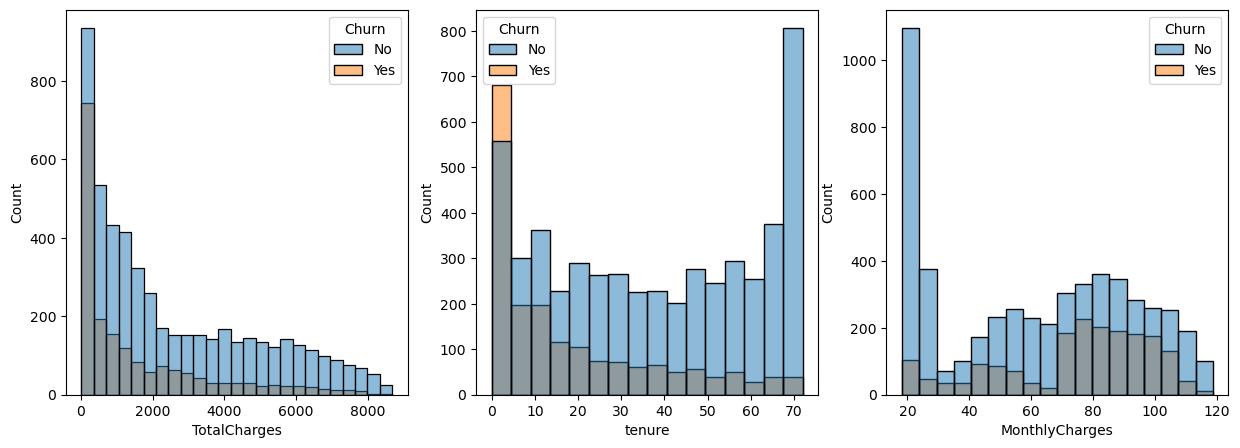

In [273]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.histplot(data=df, x='TotalCharges', hue='Churn', ax=axes[0])
sns.histplot(data=df, x='tenure', hue='Churn', ax=axes[1])
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[2])
plt.show()

Unsuprisingly we see lower TotalCharges and Tenure (churned customers are those with a short lifetime). We also see that there is a clump with higher monthly charges and a lot of the customers with low monthly charges do not churn

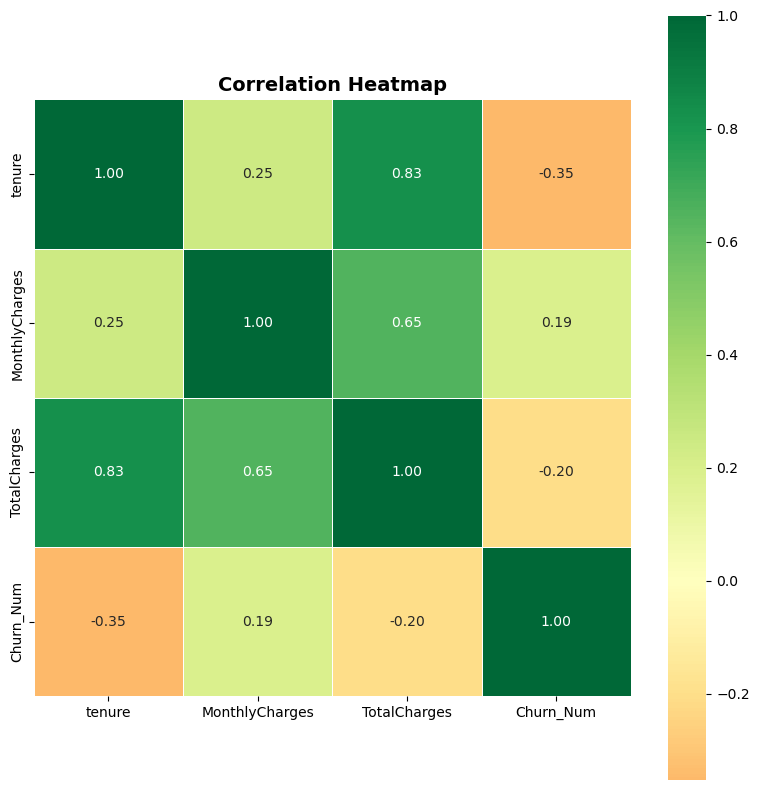

In [274]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges","Churn_Num"]].copy()
plt.figure(figsize=(8, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()

The negative correlation of tenure and TotalCharges seems to be in line with what the distributions showed above: Customers that were customers for less time churned. The Monthly Charges having a positive correlation also seems match what the distribution showed

### Contract Type and Churn

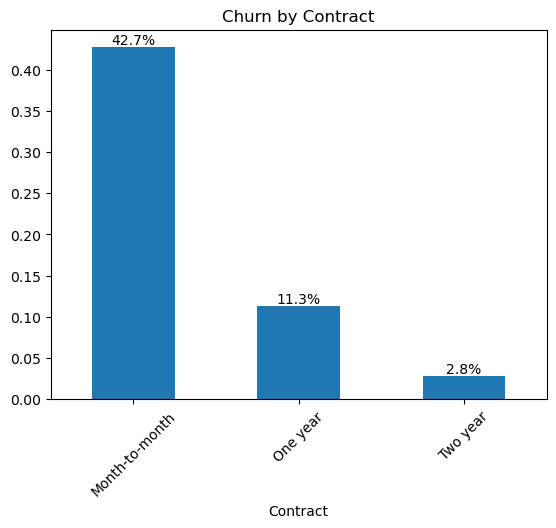

In [275]:
churn_rates_by_contract =  df.groupby('Contract')['Churn_Num'].mean()
churn_rates_by_contract.plot(kind='bar', title='Churn by Contract')
for i, rate in enumerate(churn_rates_by_contract):
    plt.text(i, rate, f"{rate*100:.1f}%", ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

Churn is significantly higher for month to month contracts

<Axes: xlabel='tenure', ylabel='Count'>

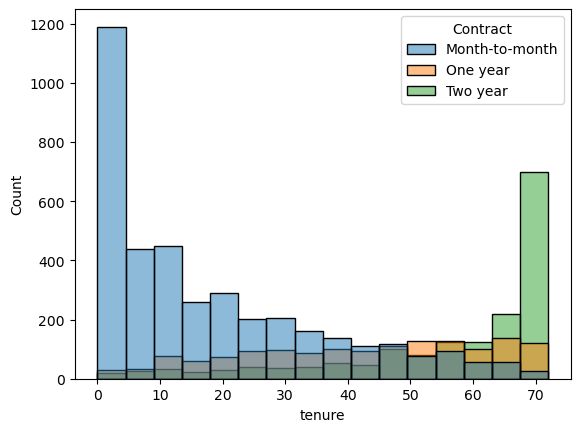

In [276]:
sns.histplot(data=df, x='tenure', hue='Contract')

However, is this because Month-to-month contracts have lower tenure? Or vice-versa?

### Churn rates by service

In [277]:
service_columns = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']

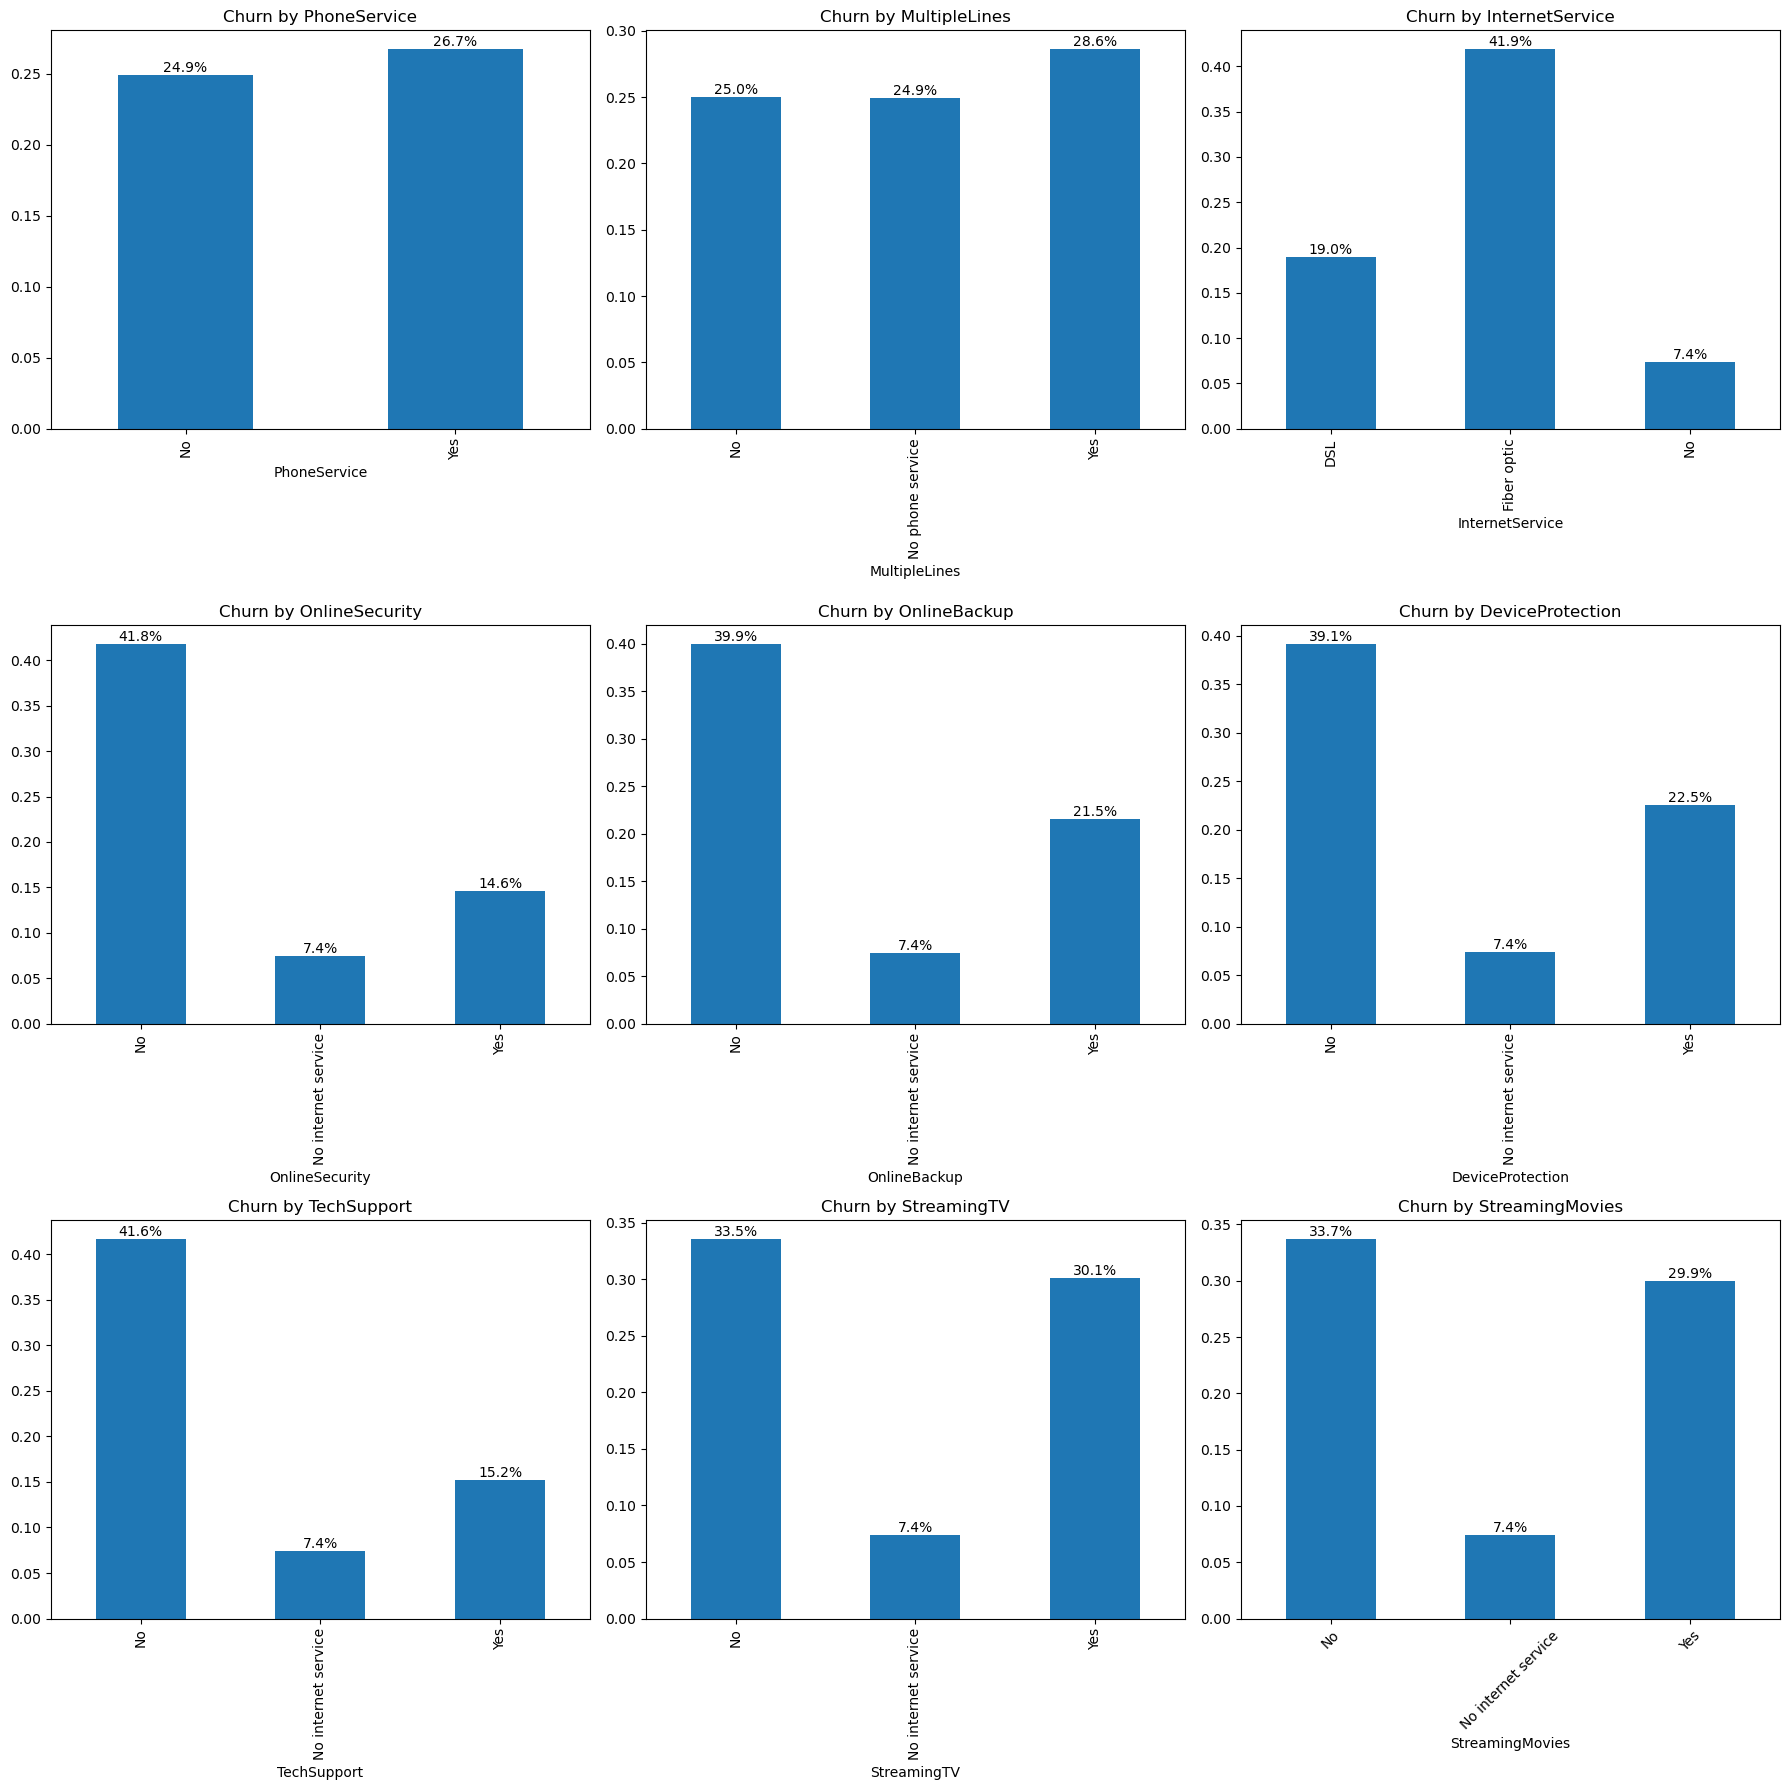

In [278]:
fig, axes = plt.subplots(3,3, figsize=(18,18))
for col, ax in zip(service_columns, axes.ravel()):
    churn_rates_by_service = df.groupby(col)['Churn_Num'].mean()
    churn_rates_by_service.plot(kind='bar', title=f'Churn by {col}', ax=ax)
    plt.xticks(rotation=45)    
    for i, rate in enumerate(churn_rates_by_service):
        ax.text(i, rate, f"{rate*100:.1f}%", ha='center', va='bottom')
fig.tight_layout() 
plt.show()

the plot above shows the churn rates for customers depending on the services that they have paid for. Using a correlation matrix we can get a better idea of what services to focus on

In [279]:
df_service_cols_encoded = df[service_columns].apply(
    lambda c: c.map(
        lambda x: 0 if x in ['No', 'No internet service', 'No phone service'] else 1)
)
df_service_cols_encoded['NumServices'] = df_service_cols_encoded.sum(axis=1)

df_service_cols_encoded = df_service_cols_encoded.join(df.Churn_Num)

<Axes: >

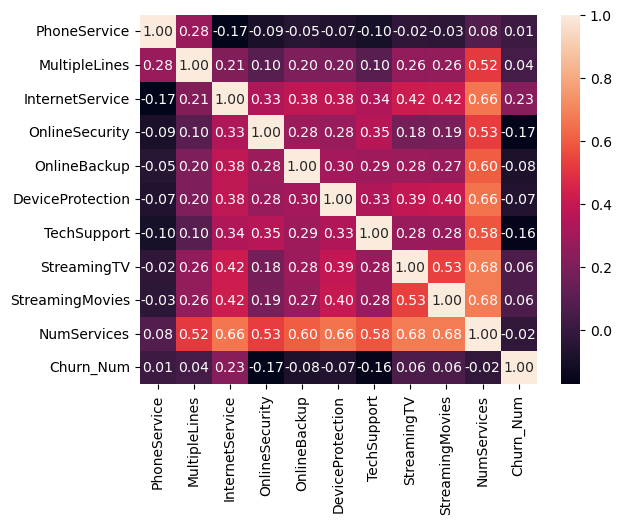

In [280]:
sns.heatmap(df_service_cols_encoded.corr(), annot=True, fmt=".2f")

Now we can see that Internet service, Online security and Tech support have correlations with churn. Refering back to the subplots above we can look at plots 3, 4 and 7 respectively

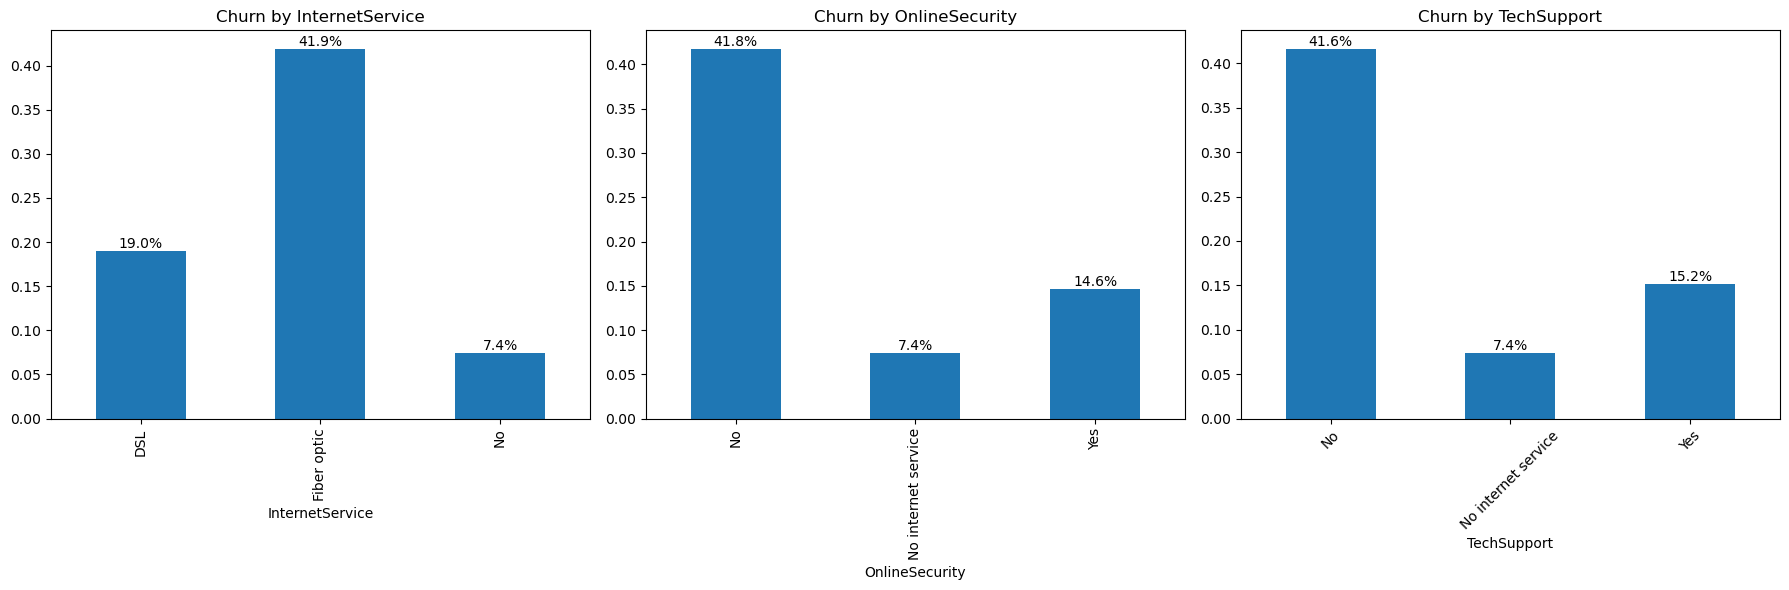

In [281]:
focus_services = ['InternetService', 'OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(1,3, figsize=(18,6))
for col, ax in zip(focus_services, axes.ravel()):
    churn_rates_by_service = df.groupby(col)['Churn_Num'].mean()
    churn_rates_by_service.plot(kind='bar', title=f'Churn by {col}', ax=ax)
    plt.xticks(rotation=45)    
    for i, rate in enumerate(churn_rates_by_service):
        ax.text(i, rate, f"{rate*100:.1f}%", ha='center', va='bottom')
fig.tight_layout() 
plt.show()

This corroborates the correlation matrix above. Customers with Fiber Optic churn at 41.9%. Customers without Online security or Tech Support churn at 41.8% and 41.6% respectively

### Number of services

<Axes: xlabel='NumServices', ylabel='Count'>

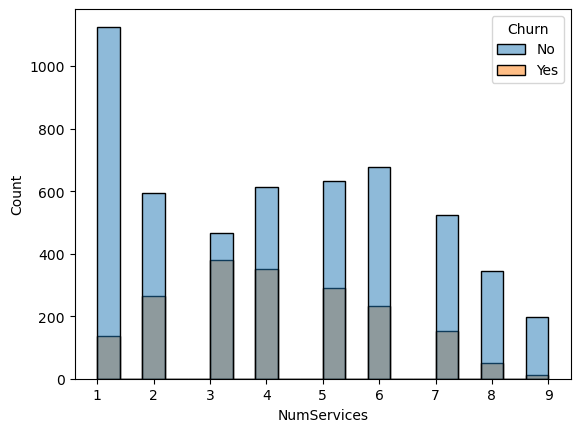

In [282]:
df_service_cols_encoded['Churn'] = df['Churn']
sns.histplot(data=df_service_cols_encoded, x='NumServices', hue='Churn', stat='count')

given the class imbalance, it might be better to normalize the data within each class

<Axes: xlabel='NumServices', ylabel='Density'>

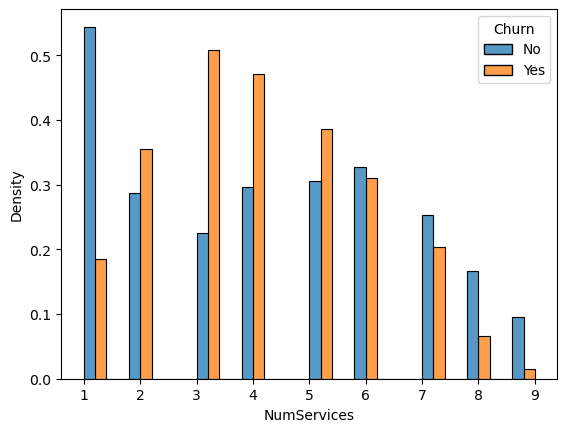

In [283]:
sns.histplot(data=df_service_cols_encoded, x='NumServices', hue='Churn',
             stat='density', common_norm=False, multiple='dodge')


In [284]:
df.Contract.value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [285]:
df['InternetService_Yes'] = df['InternetService'].apply(lambda x: 1 if x != 'No' else 0)
df['OnlineSecurity_Yes'] = df['OnlineSecurity'].apply(lambda x: 1 if x == 'Yes' else 0)
df['TechSupport_Yes'] = df['TechSupport'].apply(lambda x: 1 if x == 'Yes' else 0)

pd.pivot_table(df, 
               values='Churn_Num', 
               index=['OnlineSecurity_Yes'], 
               columns=['TechSupport_Yes'], 
               aggfunc='mean')

TechSupport_Yes,0,1
OnlineSecurity_Yes,,
0,0.334151,0.223280
1,0.213043,0.090082


The higher rate of churn for the customers with neither Online Security or Tech Support indicate that there may be a interaction effect. Therefore these features should be added into our modeling

## Modelling
### Feature Engineering

To start the modelling we need to transform some variables

1. `NewCustomer_Yes` and `TenureGroup`: these features provide a variable to capture what we have seen in the tenure distributions above: that new customers have a higher rate of churn. While it is captured in the `tenure` variable itself, providing extra variables makes it easier for models to capture this effect
2. **N-Gram columns**: Combinations of some the categorical variables - this again makes it easier for models to capture these interaction effects (E.g. customers who are on Month-to-month contracts and not subscribing to Internet service), especially important for linear models which would not be able to
3. `AvgMonthlyCharges` similar to `MonthlyCharges`
4. `NumServices` a count of the number of services the customer subscribes to

In [286]:
from itertools import combinations

# loading data again to remove any new featues:
df = pd.read_csv('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

# New Customer 
df["NewCustomer_Yes"] = df["tenure"] < 3
df['TenureGroup'] = pd.cut(df['tenure'],
    bins=[0, 3, 12, 24, 48, 72], 
    labels=['0-3m', '3-12m', '1-2yr', '2-4yr', '4+yr'],
    include_lowest=True)

df['AvgMonthlyCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

service_columns = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
      'StreamingTV', 'StreamingMovies']

df['NumServices'] = (~df[service_columns].isin(['No', 'No internet service', 'No phone service'])).sum(axis=1)

#N-grams
ngram_cols = ['Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport', 'TenureGroup', 'NewCustomer_Yes']

bigram_cols = []
trigram_cols = []
for col1, col2 in combinations(ngram_cols, 2):
    df[f'BG_{col1}_{col2}'] = df[col1].astype(str) + '_' + df[col2].astype(str)
    bigram_cols.append(f'BG_{col1}_{col2}')

for col1,col2,col3 in combinations(ngram_cols, 3):
    df[f'TG_{col1}_{col2}_{col3}'] = df[col1].astype(str) + '_' + df[col2].astype(str) + '_' + df[col3].astype(str)
    trigram_cols.append(f'TG_{col1}_{col2}_{col3}')

df = pd.get_dummies(df, columns=['gender', 'Partner', 'SeniorCitizen', 'Dependents'], drop_first=True)

### Training

In [287]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer



In [288]:
cat_cols = ['PhoneService',
    'MultipleLines',          
    'InternetService',
    'OnlineSecurity',         
    'OnlineBackup',
    'DeviceProtection',       
    'TechSupport',            
    'StreamingTV',
    'StreamingMovies',        
    'Contract',     
    'PaperlessBilling',       
    'PaymentMethod',
    'TenureGroup'          
]
dummy_cols = ['gender_Male', 'Partner_Yes', 'SeniorCitizen_1', 'Dependents_Yes', 'NewCustomer_Yes']

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlyCharges']


In [301]:
X = df.drop(['customerID', 'Churn', 'Churn_Num'], axis=1)
y = df['Churn_Num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

lr_ct = ColumnTransformer([('scaler', StandardScaler(), numerical_cols),
                           ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
                           ('ngrams', TargetEncoder(smooth=10), bigram_cols + trigram_cols),
                           ('dummy_cols', 'passthrough', dummy_cols)],
                           remainder='drop')

lr_model = make_pipeline(lr_ct, LogisticRegression(C=1, random_state=42))

lr_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outpu

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(lr_model, X, y, cv=skf, scoring='roc_auc')

lr_roc_avg, lr_roc_std = scores.mean(), scores.std()
print(f'ROC AUC: {lr_roc_avg:.4f} +/- {lr_roc_std:.4f}')

In [290]:
gb_ct = ColumnTransformer([('scaler', 'passthrough', numerical_cols),
                           ('categorical', OrdinalEncoder(), cat_cols),
                           ('ngrams', TargetEncoder(smooth=10), bigram_cols + trigram_cols),
                           ('dummy_cols', 'passthrough', dummy_cols)],
                           remainder='drop')

gb_model = make_pipeline(gb_ct, GradientBoostingClassifier(min_samples_leaf=20, random_state=42))

scores = cross_val_score(gb_model, X, y, cv=skf, scoring='roc_auc')
gb_roc_avg, gb_roc_std = scores.mean(), scores.std()
print(f'ROC AUC: {gb_roc_avg:.4f} +/- {gb_roc_std:.4f}')

ROC AUC: 0.8453 +/- 0.0172


In [291]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting'],
    'CV AUC': [lr_roc_avg,  gb_roc_avg],
    'CV Std': [lr_roc_std, gb_roc_std]
})

results

,Model,CV AUC,CV Std
0,Logistic Regression,0.848161,0.016086
1,Gradient Boosting,0.845298,0.017248


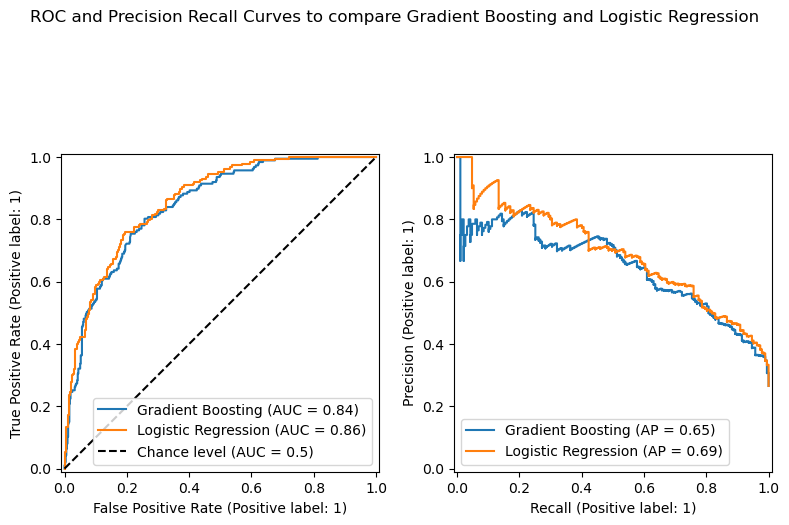

In [292]:
fig, axes = plt.subplots(1,2, figsize=(8,6))
lr_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
gbt_roc = RocCurveDisplay.from_estimator(
    gb_model, X_test, y_test, ax=axes[0], name='Gradient Boosting')
lr_roc = RocCurveDisplay.from_estimator(
    lr_model, X_test, y_test, ax=axes[0], name='Logistic Regression', plot_chance_level=True)
gb_pr = PrecisionRecallDisplay.from_estimator(
    gb_model, X_test, y_test, ax=axes[1], name='Gradient Boosting')
lr_pr = PrecisionRecallDisplay.from_estimator(
    lr_model, X_test, y_test, ax=axes[1], name='Logistic Regression')
fig.suptitle("ROC and Precision Recall Curves to compare Gradient Boosting and Logistic Regression")
plt.tight_layout()

it is suprising that the performance of the Logistic Regression is so comparable to the Gradient Boosting model. This indicates that the relationship of the data to the target is simplistic enough that a Linear Model is able to model it well. Going forward the Logistic Regression model will be chosen as the model's coefficients make for more simplistic interpretation

### Feature Importance

<Axes: ylabel='feature'>

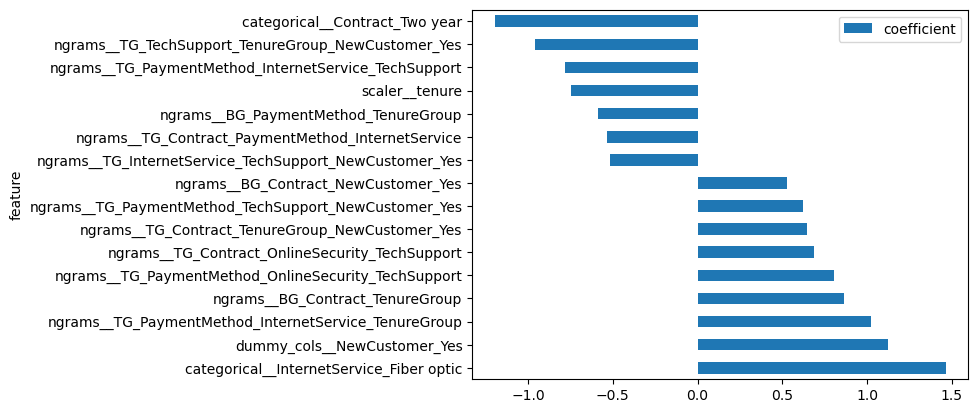

In [293]:
# Extract coefficients from the logistic regression step
feature_names = lr_model['columntransformer'].get_feature_names_out()

coefficients = lr_model['logisticregression'].coef_[0]

# Combine into a readable dataframe
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).set_index('feature').sort_values('coefficient', ascending=False)

coef_df[coef_df.coefficient.abs() >0.5].plot.barh()


We can see that a lot of the features derived from `tenure` are significant, and the services which were found to have higher different rates from the EPA (Online Security and Tech Support) also seem to have ngrams that are significant

## Optimising Performance for Cost Sensitive Scenario

This model was trained to maximise the Receiving Operating Characterist Area under the Curve - in short this means that it aims to become the best discriminator between customers who churn and those that won't

In [294]:
lr_model.fit(X_train, y_train)

print(classification_report(y_test, lr_model.predict(X_test), target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.92      0.88       518
       Churn       0.70      0.51      0.59       187

    accuracy                           0.81       705
   macro avg       0.77      0.71      0.73       705
weighted avg       0.80      0.81      0.80       705



The model predicts a probability of churn and decides that those with a proba over 0.5 are churns and those that are less will not. From the Classification Report above we can see that the accuracy is 80%. However the recall of Churns is only 0.59, while this can be typical in situations where there is class imbalance, is this model optimising for the value of the business?

Given that we do not have a perfect predictor, do we want to consider the cost of failing to identify a churning customer (False Negative) the same as a mistakenly predicting one (False Positive)? As the cost of acquiring new customers is greater than retaining, we can assume that a model which biases recalling more churners would be more relevant for the business.

This is where tuning of the decision threshold becomes relevant. We can input hypothetical costs of False Negatives, False Positives, and True Positives and tune the decision threshold to minimise loss.

The costs are shown in the table: The cost of failing to identify the churning customer is -5, the cost of a False Positive is -1 (cost of retention scheme), the Cost of a True Positive is -2.25 $$expectedretentioncost =  - 1 + (-5 * (1-retention success rate))$$ where the retention_success_rate is 0.75

|  | Predicted: No | Predicted: Yes |
|--|--------------|----------------|
| **Actual: No**  | 0  | -1 |
| **Actual: Yes** | -5 | -2.25|

In [295]:
retention_success_rate = 0.75
expected_retention_cost = -1 + (-5*(1-retention_success_rate))
cost_matrix = np.array([
    [0,-1],
    [-5,expected_retention_cost]
])

print(cost_matrix)

[[ 0.   -1.  ]
 [-5.   -2.25]]


The sum of this cost matrix multiplied by the confusion matrix is the amount of loss that the predictor has. We can tune a model to optimise for this and then compare the costs with the default predictor

In [296]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import confusion_matrix, make_scorer

def churn_cost_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return (cm * cost_matrix).sum()

churn_cost_scorer = make_scorer(churn_cost_score)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

tuned_threshold = TunedThresholdClassifierCV(
    estimator=lr_model,
    scoring=churn_cost_scorer,
    cv=skf,
    n_jobs=-1,
    store_cv_results=True,
    random_state=42
)
default_score = cross_val_score(lr_model, X_train, y_train, 
                                cv=skf, 
                                scoring=churn_cost_scorer).mean()

tuned_threshold.fit(X_train, y_train)
best_threshold = tuned_threshold.best_threshold_

print(f"Optimal threshold: {best_threshold:.2f}")
print(classification_report(y_test, tuned_threshold.predict(X_test), target_names=['No Churn', 'Churn']))

Optimal threshold: 0.29
              precision    recall  f1-score   support

    No Churn       0.91      0.77      0.83       518
       Churn       0.55      0.78      0.64       187

    accuracy                           0.77       705
   macro avg       0.73      0.77      0.74       705
weighted avg       0.81      0.77      0.78       705



Now the recall is much higher! While consequently, the precision is much lower.

### Looking at the newly identified customers

Text(50.722222222222214, 0.5, 'Actual')

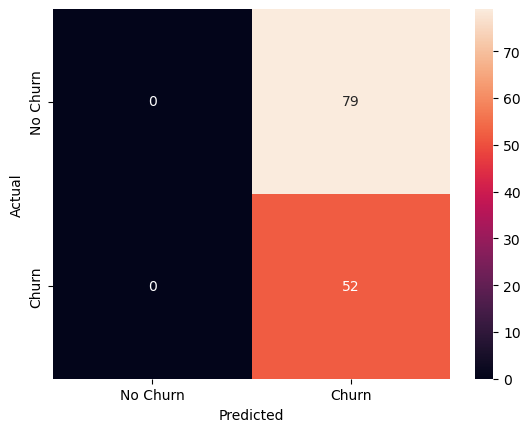

In [297]:
new_preds_idxs = (tuned_threshold.predict_proba(X_test)[:, 1] >= best_threshold) & (tuned_threshold.predict_proba(X_test)[:, 1] < 0.5)

conf_mat = confusion_matrix(y_test[new_preds_idxs], tuned_threshold.predict(X_test)[new_preds_idxs])

sns.heatmap(conf_mat, annot=True)
plt.xticks([0.5, 1.5], ['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.yticks([0.5, 1.5], ['No Churn', 'Churn'])
plt.ylabel('Actual')
# print(churn_cost_score(y_test[new_preds_idxs], tuned_threshold.predict(X_test)[new_preds_idxs]))
# print(churn_cost_score(y_test[new_preds_idxs], lr_model.predict(X_test)[new_preds_idxs]))

In [298]:
marginal_precision = conf_mat[1][1] / (conf_mat[1][1] + conf_mat[0][1])
print(f"Marginal Precision: {marginal_precision:.2f}")

Marginal Precision: 0.40


Confusion Matrix above shows the performance on the predictions between the tuned threshold and the default - I.e. all of these customers would've been predicted as non-churners. The Precision (and in this case accuracy) is only 39% - while it wouldve been 61% in the default scenario. However by inputting the costs below (where false negatives are penalized heavier than false positives) we can see that this model reduces loss compared to a default tuning

In [299]:
# cost of new predictions = -3.5*Actual Churns + -1 * False Positives
print('cost of new predictions:', expected_retention_cost*conf_mat[1][1] + -1*conf_mat[0][1])

# cost of default model = -5 * Actual Churns (False Negatives)
print('cost of old model predictions:', -5*conf_mat[1][1])


cost of new predictions: -196.0
cost of old model predictions: -260


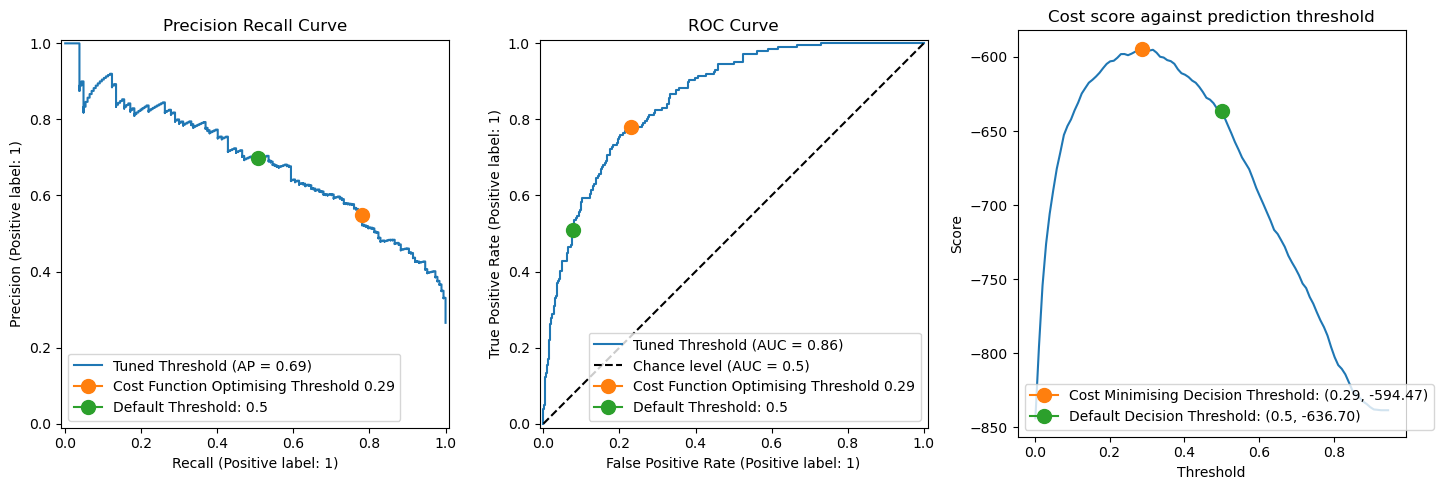

In [300]:
from sklearn.metrics import precision_score, recall_score

def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred)

def false_positive_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, _, _ = cm.ravel()
    tnr = tn / (tn + fp)
    return 1 - tnr


fig, axes = plt.subplots(1,3, figsize=(15,5))

# Precision Recall Curve
pr_curve = PrecisionRecallDisplay.from_estimator(tuned_threshold, X_test, y_test, ax=axes[0], name='Tuned Threshold')
axes[0].plot(
    recall_score(y_test, tuned_threshold.predict(X_test)),
    precision_score(y_test, tuned_threshold.predict(X_test)),
    markersize=10,
    marker='o',
    label=f'Cost Function Optimising Threshold {best_threshold:.2f}'
)
axes[0].plot(
    recall_score(y_test, lr_model.predict(X_test)),
    precision_score(y_test, lr_model.predict(X_test)),
    markersize=10,
    marker='o',
    label=f'Default Threshold: 0.5'
)

axes[0].set_title('Precision Recall Curve')
axes[0].legend()

# ROC Curve
roc_curve = RocCurveDisplay.from_estimator(tuned_threshold, X_test, y_test, 
                                           ax=axes[1], 
                                           name='Tuned Threshold',
                                           plot_chance_level=True)
axes[1].plot(
    false_positive_rate(y_test, tuned_threshold.predict(X_test)),
    true_positive_rate(y_test, tuned_threshold.predict(X_test)),
    markersize=10,
    marker='o',
    label=f'Cost Function Optimising Threshold {best_threshold:.2f}',
)
axes[1].plot(
    false_positive_rate(y_test, lr_model.predict(X_test)),
    true_positive_rate(y_test, lr_model.predict(X_test)),
    markersize=10,
    marker='o',
    label=f'Default Threshold: 0.5'
)
axes[1].set_title('ROC Curve')
axes[1].legend()

# Cost function plotting
axes[2].plot(
    tuned_threshold.cv_results_['thresholds'],
    tuned_threshold.cv_results_['scores']
)

axes[2].plot(
    tuned_threshold.best_threshold_,
    tuned_threshold.best_score_,
    markersize=10,
    marker='o',
    label=f'Cost Minimising Decision Threshold: ({tuned_threshold.best_threshold_:.2f}, {tuned_threshold.best_score_:.2f})'
)

axes[2].plot(
    0.5,
    default_score,
    markersize=10,
    marker='o',
    label=f'Default Decision Threshold: (0.5, {default_score:.2f})'
)

axes[2].legend(loc='lower left')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Cost score against prediction threshold')
plt.tight_layout()

The plots above essentially show that the cost function is optimised when a higher recall and therefore higher false positive rate is selected

# END